# Phase Transition Temperature Estimation in a 2D Ising Model Using Deep Learning

# Dependencies

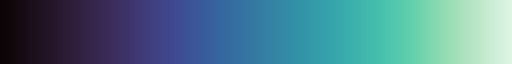

In [1]:
import matplotlib
matplotlib.use('Agg')
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

#import torcheval.metrics.functional as metrics
from torcheval.metrics import MulticlassConfusionMatrix

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

import os
import glob
import re
from pathlib import Path

np.random.seed(42)
sns.set_style("darkgrid")
sns.color_palette("mako", as_cmap=True)

# Data Formatting
![Figure1](https://imgur.com/ITmxFFF.png)

In [2]:
def load_data_files(data_dir="../data"):
    # Get all files in the data directory
    all_files = os.listdir(data_dir)
    
    # Filter files that match the Dataset pattern and extract temperatures
    temperatures = []
    for filename in all_files:
        match = re.match(r"Dataset(\d+\.\d+)\.txt", filename)
        if match:
            temperatures.append(float(match.group(1)))
    
    # Sort temperatures in ascending order
    temperatures.sort()
    T = np.array(temperatures)
    
    # Create file paths
    Paths = [os.path.join(data_dir, f"Dataset{t:.3f}.txt") for t in T]
    
    # Read data frames
    DataFrames = [pd.read_csv(path, sep=r'\s+', header=None) for path in Paths]
    
    return T, DataFrames
T, DataFrames = load_data_files()

In [3]:
def Create_DataFrame(df_list):
    df =  pd.concat(df_list)
    return df
    # Still need to consider whether to remove duplicates
    
Data_set = Create_DataFrame(DataFrames)
Data_set

,0,1,2,3,4,5,6,7,8,9,...,135,136,137,138,139,140,141,142,143,144
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,0
1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,0
2,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,0
3,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,0
4,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,1,-1,-1,-1,-1,-1,1,1,...,-1,1,-1,-1,-1,1,1,-1,-1,1
9996,-1,1,1,1,1,-1,-1,-1,-1,-1,...,1,-1,1,-1,-1,1,1,-1,1,1
9997,-1,1,1,1,1,1,1,1,-1,1,...,1,1,-1,1,1,-1,1,1,1,1
9998,1,1,1,1,-1,-1,-1,1,-1,-1,...,1,-1,-1,-1,1,-1,1,1,1,1


# NN Implementation

## Dataset Class

In [4]:
class Data(Dataset):
  def __init__(self , Predictors , Targets):
    self.x = Predictors
    self.y = Targets
    self.len = len(Predictors)
    
  def __getitem__(self, index):
    #print (len(self.x),len(self.y))
    return self.x[index], self.y[index]

  def __len__(self):
    return self.len

## NN Architecture


In [5]:
class NN(nn.Module):
  def __init__(self , Layers):
    super(NN , self).__init__()
    self.__Layers__ = nn.ModuleList()
    self.__BatchNorm__ = nn.ModuleList()

    for i in range(len(Layers) - 1) :
      Layer = nn.Linear(in_features = Layers[i] , out_features = Layers[i+1])
      torch.nn.init.kaiming_uniform_(Layer.weight , nonlinearity = "relu")
      self.__Layers__.append(Layer)

      BN = nn.BatchNorm1d(num_features = Layers[i+1] )
      self.__BatchNorm__.append(BN)

    self.state_dict = self.__Layers__.state_dict

#-------------------------------------------------------------------------------
  def forward(self , X):
    L = len(self.__Layers__)

    for l,Layer in enumerate(self.__Layers__):
      if l < L-1:
        X = F.relu(self.__BatchNorm__[l](Layer(X)))
      else:
        X =  Layer(X)
    return X

## Training Loop


In [6]:
def Train(Model, Data_Train_Loader, Data_Val_Loader, Criterion, Optimizer, Epochs):
    Results = {
        "Training_Loss": [], "Training_Accuracy": [],
        "Validation_Loss": [], "Validation_Accuracy": [],
        "Validation_Precision": [], "Validation_Recall": [], "Validation_F1": []
    }

    for epoch in range(Epochs):
        # TRAINING
        Model.train()
        train_loss = 0.0
        all_train_preds, all_train_labels = [], []

        for X, Y in Data_Train_Loader:
            Optimizer.zero_grad()
            Y_hat = Model(X)
            loss = Criterion(Y_hat, Y)
            loss.backward()
            Optimizer.step()


            train_loss += loss.item() * X.size(0) # Multiply by batch size
            preds = torch.argmax(Y_hat, dim=1)
            all_train_preds.extend(preds.detach().cpu().numpy())
            all_train_labels.extend(Y.detach().cpu().numpy())

        # Average loss per sample (not per batch)
        avg_train_loss = train_loss / len(Data_Train_Loader.dataset)
        train_acc = accuracy_score(all_train_labels, all_train_preds)

        # VALIDATION
        Model.eval()
        val_loss = 0.0
        all_val_preds, all_val_labels = [], []
        with torch.no_grad():
            for X, Y in Data_Val_Loader:
                Y_hat = Model(X)
                loss = Criterion(Y_hat, Y)

                val_loss += loss.item() * X.size(0)  # Multiply by batch size

                preds = torch.argmax(Y_hat, dim=1)
                all_val_preds.extend(preds.detach().cpu().numpy())
                all_val_labels.extend(Y.detach().cpu().numpy())

        # Average loss per sample in validation
        avg_val_loss = val_loss / len(Data_Val_Loader.dataset)
        val_acc = accuracy_score(all_val_labels, all_val_preds)
        val_prec = precision_score(all_val_labels, all_val_preds, average="macro", zero_division=0)
        val_rec = recall_score(all_val_labels, all_val_preds, average="macro", zero_division=0)
        val_f1 = f1_score(all_val_labels, all_val_preds, average="macro", zero_division=0)

        # Save results
        Results["Training_Loss"].append(avg_train_loss)
        Results["Training_Accuracy"].append(train_acc)
        Results["Validation_Loss"].append(avg_val_loss)
        Results["Validation_Accuracy"].append(val_acc)
        Results["Validation_Precision"].append(val_prec)
        Results["Validation_Recall"].append(val_rec)
        Results["Validation_F1"].append(val_f1)

        # Print every x epochs
        if epoch % 2 == 0 or epoch == Epochs - 1:
            print(f"Epoch {epoch+1}/{Epochs}: "
                  f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                  f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return Results

## Training


### Data Preparation

In [7]:
# Train - Test split
x = Data_set.iloc[:,:-1]
y = Data_set.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y, shuffle=True)

#-------------------------------------------------------------------------------
X_train = torch.tensor(X_train.values , dtype=torch.float32) 
X_test = torch.tensor(X_test.values , dtype=torch.float32)
y_train = torch.tensor(y_train.values , dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

#-------------------------------------------------------------------------------
Data_Train = Data(Predictors = X_train , Targets =  y_train)
Data_Test = Data(Predictors = X_test , Targets =  y_test)

#------------------------------------------------------------------------------
batch_size_train = X_train.shape[0]
batch_size_test = X_test.shape[0]

print(f"batch_size_train = {batch_size_train} \n batch_size_test = {batch_size_test}")

Train_Loader = DataLoader(Data_Train , batch_size = batch_size_train , shuffle = False )
Test_Loader = DataLoader(Data_Test , batch_size = batch_size_test , shuffle = False)

batch_size_train = 150000 
 batch_size_test = 50000


### Model Configuration

In [8]:
# Hyperparameters
lr = 0.0001
weight_decay = 1e-4
Epochs = 100

# Architecture
l0 = X_train.shape[1]
l1 = int(.8 * l0)
l2 = int(.6 * l0)
l3 = int(.5 * l0)

Layers = [l0,l1,l2,l3,2]
print(f"Model architecture - layers: {Layers}")
Model_Balanced = NN(Layers)

# Loss and optimization
Criterion = nn.CrossEntropyLoss()
Optimizer =  torch.optim.Adam(Model_Balanced.parameters(), lr=lr , weight_decay=weight_decay)

Model architecture - layers: [144, 115, 86, 72, 2]


In [9]:
# TRAINING CELL
Results = Train(Model = Model_Balanced , Data_Train_Loader = Train_Loader , Data_Val_Loader = Test_Loader ,
                Criterion  = Criterion , Optimizer = Optimizer , Epochs =  Epochs)

Epoch 1/100: Train Loss: 0.8699, Train Acc: 0.3646, Val Loss: 0.8129, Val Acc: 0.4566


Epoch 3/100: Train Loss: 0.7982, Train Acc: 0.3821, Val Loss: 0.7656, Val Acc: 0.4509


Epoch 5/100: Train Loss: 0.7331, Train Acc: 0.3981, Val Loss: 0.7339, Val Acc: 0.4501


Epoch 7/100: Train Loss: 0.6729, Train Acc: 0.4142, Val Loss: 0.7046, Val Acc: 0.4509


Epoch 9/100: Train Loss: 0.6193, Train Acc: 0.7712, Val Loss: 0.6657, Val Acc: 0.4542


...

Epoch 93/100: Train Loss: 0.2209, Train Acc: 0.9315, Val Loss: 0.2211, Val Acc: 0.9281


Epoch 95/100: Train Loss: 0.2191, Train Acc: 0.9324, Val Loss: 0.2192, Val Acc: 0.9292


Epoch 97/100: Train Loss: 0.2174, Train Acc: 0.9332, Val Loss: 0.2174, Val Acc: 0.9303


Epoch 99/100: Train Loss: 0.2157, Train Acc: 0.9337, Val Loss: 0.2158, Val Acc: 0.9311


Epoch 100/100: Train Loss: 0.2149, Train Acc: 0.9340, Val Loss: 0.2149, Val Acc: 0.9316


In [10]:
# Preserve training Results before the per-temperature validation loop overwrites them
_train_results = dict(Results)


In [11]:
# Plots
fig1 , ax1 = plt.subplots()
sns.lineplot(x = range(Epochs) , y = Results["Training_Loss"] , label = "Training_CrossEntropy" , ax = ax1)
sns.lineplot(x = range(Epochs) , y = Results["Validation_Loss"] , label = "Validation_CrossEntropy"  ,ax = ax1).set(title = "CrossEntropy",
                                                                                                          xlabel = "Epochs",
                                                                                                          ylabel = "CrossEntropyLoss")


fig2 , ax2 = plt.subplots()
sns.lineplot(x = range(Epochs) , y = Results["Training_Accuracy"] , label = "Training_Accuracy" , ax = ax2)
sns.lineplot(x = range(Epochs) , y = Results["Validation_Accuracy"] , label = "Validation_Accuracy"  ,ax = ax2).set(title="Accuracy",
                                                                                                       xlabel = "Epochs")
os.makedirs('../plots', exist_ok=True)
fig1.savefig('../plots/training_cross_entropy.png', dpi=150, bbox_inches='tight')
fig2.savefig('../plots/training_accuracy.png', dpi=150, bbox_inches='tight')
plt.close('all')


In [12]:
fig3 , ax3 = plt.subplots()
sns.lineplot(x = range(Epochs) , y = Results["Validation_Precision"] , label = "Validation_Precision" , ax = ax3)
sns.lineplot(x = range(Epochs) , y = Results["Validation_F1"] , label = "Validation_F1" , ax = ax3)
sns.lineplot(x = range(Epochs) , y = Results["Validation_Recall"] , label = "Validation_Recall"  ,ax = ax3).set(title="Score-Macro Averaged",
                                                                                                       xlabel = "Epochs")
fig3.savefig('../plots/validation_scores.png', dpi=150, bbox_inches='tight')
plt.close('all')


In [13]:
if y_test.dtype != torch.long:
    y_test = y_test.long()

positive_class = 1  
y_test_bin = (y_test == positive_class).long() 

metric = MulticlassConfusionMatrix(num_classes=2, normalize='true')

# Pass data through the model
with torch.no_grad():
    X_input = torch.tensor(X_test, dtype=torch.float32)
    logits = Model_Balanced(X_input)
    preds_multiclass = torch.argmax(logits, dim=1)
    preds_bin = (preds_multiclass == positive_class).long()  # Convert predictions to binary

    metric.update(input=preds_bin, target=y_test_bin)

# Visualize the confusion matrix
conf_matrix = metric.compute().cpu().numpy()
class_names = [r'$T < Tc_{\text{seed}}$', r'$T > Tc_{\text{seed}}$']  # Binary labels

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, cmap='Blues', annot=True, fmt=".2f",
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title('Binary Confusion Matrix (Normalized)')
plt.xlabel('Prediction')
plt.ylabel('True')
plt.savefig('../plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close()

/tmp/ipykernel_24819/1697055374.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_input = torch.tensor(X_test, dtype=torch.float32)


# Critical Temperature Estimation
We now use our trained model on the different datasets generated at various temperatures to evaluate how well it performs on that data. Naturally, as the model is evaluated at temperatures close to the real critical temperature, it will be unable to distinguish between an ordered and a disordered microstate. We therefore expect the accuracy metric to drop sharply in temperature regions near the true critical temperature. This is the point where we estimate the true critical temperature of the system!

In [14]:
def Validate_t(Model, Data_Val_Loader):
    Results = {
        "Training_Loss": [], "Training_Accuracy": [],
        "Validation_Loss": [], "Validation_Accuracy": [],
        "Validation_Precision": [], "Validation_Recall": [], "Validation_F1": []}
    Model.eval()
    val_loss = 0.0
    all_val_preds, all_val_labels = [], []
    with torch.no_grad():
        for X, Y in Data_Val_Loader:
            Y_hat = Model(X)
            loss = Criterion(Y_hat, Y)

            val_loss += loss.item() * X.size(0)  # Multiply by batch size

            preds = torch.argmax(Y_hat, dim=1)
            all_val_preds.extend(preds.detach().cpu().numpy())
            all_val_labels.extend(Y.detach().cpu().numpy())

        # Average loss per sample in validation
        avg_val_loss = val_loss / len(Data_Val_Loader.dataset)
        val_acc = accuracy_score(all_val_labels, all_val_preds)
        val_prec = precision_score(all_val_labels, all_val_preds, average="macro", zero_division=0)
        val_rec = recall_score(all_val_labels, all_val_preds, average="macro", zero_division=0)
        val_f1 = f1_score(all_val_labels, all_val_preds, average="macro", zero_division=0)

        # Save results
        Results["Validation_Loss"].append(avg_val_loss)
        Results["Validation_Accuracy"].append(val_acc)
        Results["Validation_Precision"].append(val_prec)
        Results["Validation_Recall"].append(val_rec)
        Results["Validation_F1"].append(val_f1)


    return Results

In [15]:
Accuracies = []
for t,df in zip(T,DataFrames):
    x = df.iloc[:,:-1]
    y = df.iloc[:,-1]

    #-------------------------------------------------------------------------------
    X = torch.tensor(x.values , dtype=torch.float32) 
    y = torch.tensor(y.values, dtype=torch.long)

    #-------------------------------------------------------------------------------
    data = Data(Predictors = X , Targets =  y)
    
    #------------------------------------------------------------------------------
    batch_size = X.shape[0]
    print(f"batch_size = {batch_size}")

    Loader = DataLoader(data , batch_size = batch_size , shuffle = False )
    Results = Validate_t(Model_Balanced, Loader)
    Accuracies.append(Results["Validation_Accuracy"])
    
Accuracies = np.array(Accuracies).reshape(-1,)

batch_size = 10000


batch_size = 10000


batch_size = 10000


batch_size = 10000


batch_size = 10000


...

batch_size = 10000


batch_size = 10000


batch_size = 10000


batch_size = 10000


batch_size = 10000


In [16]:
# Read the exact Tc_seed used by the C++ simulator
import json as _jp
with open('../data/run_params.json') as _fp:
    _params = _jp.load(_fp)
Tc_seed = float(_params['Tc_seed'])

idx_min = np.argmin(Accuracies)
Tc_est  = T[idx_min]

plt.figure(figsize=(8, 5))
sns.lineplot(x=T, y=Accuracies, marker='o', linewidth=2.5)

plt.axvline(x=Tc_seed, color='red',  linestyle='--', linewidth=1.8,
            label=f'$T_{{c,\\mathrm{{seed}}}}$ = {Tc_seed:.3f}')
plt.axvline(x=Tc_est,  color='blue', linestyle='--', linewidth=1.8,
            label=f'$\\hat{{T}}_c$ = {Tc_est:.3f}')
plt.axvline(x=2.269,   color='green', linestyle=':',  linewidth=1.5,
            label='$T_c$ (exact) = 2.269')

plt.xlabel('Temperature', fontsize=14)
plt.ylabel('Model Accuracy', fontsize=14)
plt.title('Accuracy vs Temperature', fontsize=16, pad=15)
plt.legend(fontsize=12, loc='best')
sns.despine()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/accuracy_vs_temperature.png', dpi=150, bbox_inches='tight')
plt.close()

print(f'Tc_seed (given)  = {Tc_seed:.3f}')
print(f'Tc_est  (min acc) = {Tc_est:.3f}')
print(f'Tc_exact          = 2.269')


Tc_seed (given)  = 1.500
Tc_est  (min acc) = 1.690
Tc_exact          = 2.269


## Effect of $T_{c,\text{seed}}$ on the Estimated $T_c$

The quality of the estimated critical temperature depends directly on how close $T_{c,\text{seed}}$ is to the true value $T_c \approx 2.269$.

Training labels are defined as:

$$
\text{label} = \begin{cases} 0 & T < T_{c,\text{seed}} \\ 1 & T \geq T_{c,\text{seed}} \end{cases}
$$

so the network learns to classify configurations **relative to $T_{c,\text{seed}}$**, not the true $T_c$. Three scenarios:

| $T_{c,\text{seed}}$ | Effect |
|---|---|
| $\approx 2.269$ | Labels are nearly correct; the network learns the true phase boundary; $\hat{T}_c \approx 2.269$ |
| Moderately off | Labels near $T_c$ are noisy; the decision boundary shifts; $\hat{T}_c$ is pulled toward $T_{c,\text{seed}}$ |
| Far from $2.269$ | Large mislabeling region; the accuracy minimum reflects the label boundary, not the physics; $\hat{T}_c \approx T_{c,\text{seed}}$ |

In general, **$\hat{T}_c$ is biased toward $T_{c,\text{seed}}$**: the larger $|T_{c,\text{seed}} - 2.269|$, the larger the bias.

In [17]:
import json as _json
import os as _os

_os.makedirs('../plots', exist_ok=True)

_L = int(np.sqrt(Data_set.shape[1] - 1))
_N = _L * _L
_summary = {
    'L': _L,
    'N': _N,
    'arch': Layers,
    'epochs': Epochs,
    'total_samples': len(Data_set),
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'temperatures': T.tolist(),
    'T_min': float(T.min()),
    'T_max': float(T.max()),
    'T_n': int(len(T)),
    'num_samples_per_T': int(len(Data_set) // len(T)),
    'tc_seed': float(Tc_seed),
    'estimated_tc': float(Tc_est),
    'final_train_acc': float(_train_results['Training_Accuracy'][-1]),
    'final_val_acc':   float(_train_results['Validation_Accuracy'][-1]),
    'final_val_f1':    float(_train_results['Validation_F1'][-1]),
}

with open('../plots/run_summary.json', 'w') as _f:
    _json.dump(_summary, _f, indent=2)

print('run_summary.json saved:')
print(_json.dumps(_summary, indent=2))


run_summary.json saved:
{
  "L": 12,
  "N": 144,
  "arch": [
    144,
    115,
    86,
    72,
    2
  ],
  "epochs": 100,
  "total_samples": 200000,
  "train_samples": 150000,
  "test_samples": 50000,
  "temperatures": [
    0.01,
    0.22,
    0.43,
    0.64,
    0.85,
    1.06,
    1.27,
    1.48,
    1.69,
    1.9,
    2.11,
    2.32,
    2.53,
    2.74,
    2.95,
    3.16,
    3.37,
    3.58,
    3.79,
    4.0
  ],
  "T_min": 0.01,
  "T_max": 4.0,
  "T_n": 20,
  "num_samples_per_T": 10000,
  "tc_seed": 1.5,
  "estimated_tc": 1.69,
  "final_train_acc": 0.93398,
  "final_val_acc": 0.93164,
  "final_val_f1": 0.9302445225893003
}
